<a href="https://colab.research.google.com/github/Uday-SR/Computer-Vision2/blob/main/Impact_of_Image_Quality_on_Machine_Learning_Based_Object_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
input_dir = '/content/drive/MyDrive/Datasets/RealWaste'
os.listdir(input_dir)

['Metal', 'Glass', 'Cardboard', 'Food Organics']

In [4]:
output_dirs = {
    "Original": "/content/drive/MyDrive/Datasets/RealWaste_Original",
    "Noisy": "/content/drive/MyDrive/Datasets/RealWaste_Noisy",
    "Blurred": "/content/drive/MyDrive/Datasets/RealWaste_Blurred",
    "Dark": "/content/drive/MyDrive/Datasets/RealWaste_Dark",
    "Bright": "/content/drive/MyDrive/Datasets/RealWaste_Bright"
}

In [ ]:
for folder in output_dirs.values():
  os.makedirs(folder, exist_ok=True)

In [ ]:
for class_name in os.listdir(input_dir):
  class_path = os.path.join(input_dir, class_name)

  if not os.path.isdir(class_path):
    continue

  for dataset in output_dirs.values():
    os.makedirs(os.path.join(dataset, class_name), exist_ok=True)

  for img_name in os.listdir(class_path):
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)

    if img is None:
      continue

    # Resize
    img = cv2.resize(img, (128, 128))

    # Original

    cv2.imwrite(os.path.join(output_dirs['Original'], class_name, img_name), img)

    # Gaussian Noise

    noise = np.random.normal(0, 25, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    cv2.imwrite(os.path.join(output_dirs['Noisy'], class_name, img_name), noisy)

    #Gaussian blur

    blur = cv2.GaussianBlur(img, (7, 7), 1.5)

    cv2.imwrite(os.path.join(output_dirs['Blurred'], class_name, img_name), blur)

    #Dark Images

    dark = cv2.convertScaleAbs(img, alpha=0.5, beta=0)

    cv2.imwrite(os.path.join(output_dirs['Dark'], class_name, img_name), dark)

    #Bright Images

    bright = cv2.convertScaleAbs(img, alpha=1.0, beta=0)

    cv2.imwrite(os.path.join(output_dirs['Bright'], class_name, img_name), bright)

print("done")

done


In [14]:
## Feature Extraction for original

# Color Histogram Features

def extract_histogram_features(input_dir, bins=16):

  features = []
  labels = []
  img_paths = []

  for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)

    if not os.path.isdir(class_path):
      continue

    for dataset in output_dirs.values():
      os.makedirs(os.path.join(dataset, class_name), exist_ok=True)

    for img_name in os.listdir(class_path):
      img_path = os.path.join(class_path, img_name)

      img = cv2.imread(img_path)

      if img is None:
        continue

      # calculate histogram

      hist_r = cv2.calcHist([img], [0], None, [bins], [0, 256])
      hist_g = cv2.calcHist([img], [1], None, [bins], [0, 256])
      hist_b = cv2.calcHist([img], [2], None, [bins], [0, 256])

      # Normalize

      hist_r = cv2.normalize(hist_r, hist_r).flatten()
      hist_g = cv2.normalize(hist_g, hist_g).flatten()
      hist_b = cv2.normalize(hist_b, hist_b).flatten()

      #concatenate

      feature = np.concatenate((hist_r, hist_g, hist_b))

      features.append(feature)
      labels.append(class_name)
      img_paths.append(img_path)

  return np.array(features), labels, img_paths

In [15]:
# Edge density feature

def extract_edge_density_features(input_dir, low_threshold=100, high_threshold=200):

  features = []
  labels = []
  img_paths = []

  for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)

    if not os.path.isdir(class_path):
      continue

    for dataset in output_dirs.values():
      os.makedirs(os.path.join(dataset, class_name), exist_ok=True)

    for img_name in os.listdir(class_path):
      img_path = os.path.join(class_path, img_name)

      img = cv2.imread(img_path)

      if img is None:
        continue

      gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

      edges = cv2.Canny(gray, low_threshold, high_threshold)

      edge_pixels = np.count_nonzero(edges)

      total_pixels = gray.shape[0]*gray.shape[1]

      #compute edge density

      edge_density = edge_pixels/total_pixels

      features.append([edge_density])
      labels.append(class_name)
      img_paths.append(img_path)

  return np.array(features), labels, img_paths

In [16]:
# Texture Features

def extract_texture_features(input_dir):

    features = []
    labels = []
    image_paths = []

    for class_name in sorted(os.listdir(input_dir)):

        class_path = os.path.join(input_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for image_name in sorted(os.listdir(class_path)):

            image_path = os.path.join(class_path, image_name)

            img = cv2.imread(image_path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Mean Intensity

            mean = np.mean(gray)

            # Standard Deviation

            std = np.std(gray)

            # Entropy

            hist = cv2.calcHist([gray],[0],None,[256],[0,256])

            hist = hist.ravel()

            prob = hist / np.sum(hist)

            prob = prob[prob > 0]

            entropy = -np.sum(prob * np.log2(prob))

            # Contrast

            contrast = gray.max() - gray.min()

            # Feature Vector

            feature = [
                mean,
                std,
                entropy,
                contrast
            ]

            features.append(feature)
            labels.append(class_name)
            image_paths.append(image_path)

    return np.array(features), labels, image_paths

In [17]:
# Apply Feature extraction

#for hist

all_features = {}

for name, path in output_dirs.items():
    X, y, img_paths = extract_histogram_features(path)

    all_features[name] = {
        "X": X,
        "y": y,
        "paths": img_paths
    }

    print(f"{name}: {X.shape}")

#edge features

edge_features = {}

for name, path in output_dirs.items():

    X, y, img_paths = extract_edge_density_features(path)

    edge_features[name] = {
        "X": X,
        "y": y,
        "paths": img_paths
    }

    print(f"{name}: {X.shape}")

#texture features

texture_features = {}

for name, path in output_dirs.items():

    X, y, img_paths = extract_texture_features(path)

    texture_features[name] = {
        "X": X,
        "y": y,
        "paths": img_paths
    }

    print(name, X.shape)

Original: (2061, 48)
Noisy: (2061, 48)
Blurred: (2061, 48)
Dark: (2061, 48)
Bright: (2061, 48)
Original: (2061, 1)
Noisy: (2061, 1)
Blurred: (2061, 1)
Dark: (2061, 1)
Bright: (2061, 1)
Original (2061, 4)
Noisy (2061, 4)
Blurred (2061, 4)
Dark (2061, 4)
Bright (2061, 4)


In [38]:
#final features

final_features = {}

for dataset_name in output_dirs.keys():

    X_color = all_features[dataset_name]["X"]
    X_edge = edge_features[dataset_name]["X"]
    X_texture = texture_features[dataset_name]["X"]

    X_final = np.hstack((X_color, X_edge, X_texture))

    final_features[dataset_name] = {
        "X": X_final,
        "y": all_features[dataset_name]["y"],
        "paths": all_features[dataset_name]["paths"]
    }

    print(dataset_name, X_final.shape)

Original (2061, 53)
Noisy (2061, 53)
Blurred (2061, 53)
Dark (2061, 53)
Bright (2061, 53)


In [39]:
X_original = final_features["Original"]["X"]
X_noisy = final_features["Noisy"]["X"]

print(X_original.shape)
print(X_noisy.shape)

(2061, 53)
(2061, 53)


In [40]:
# Apply SVM

results = {}

for dataset_name, data in final_features.items():

    X = data["X"]
    y = data["y"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # SVM Pipeline
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results[dataset_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted"),
        "Confusion": confusion_matrix(y_test, y_pred),
        "Classes": np.unique(y)
    }

    print(dataset_name, "Done")

Original Done
Noisy Done
Blurred Done
Dark Done
Bright Done


In [41]:
# Performance table

performance = pd.DataFrame({
    "Image Condition": results.keys(),
    "Accuracy": [results[d]["Accuracy"] for d in results],
    "Precision": [results[d]["Precision"] for d in results],
    "Recall": [results[d]["Recall"] for d in results],
    "F1-Score": [results[d]["F1"] for d in results]
})

performance

,Image Condition,Accuracy,Precision,Recall,F1-Score
0,Original,0.883777,0.883911,0.883777,0.883132
1,Noisy,0.871671,0.871137,0.871671,0.870297
2,Blurred,0.815981,0.817186,0.815981,0.815408
3,Dark,0.878935,0.880598,0.878935,0.878268
4,Bright,0.883777,0.883911,0.883777,0.883132


In [42]:
# Accuracy drop analysis

original_accuracy = results["Original"]["Accuracy"]

drop = {}

for name in results:

    acc = results[name]["Accuracy"]

    drop[name] = ((original_accuracy - acc) / original_accuracy) * 100

drop

{'Original': 0.0,
 'Noisy': 1.3698630136986318,
 'Blurred': 7.671232876712334,
 'Dark': 0.5479452054794578,
 'Bright': 0.0}

In [43]:
drop_df = pd.DataFrame({
    "Image Condition": drop.keys(),
    "Accuracy Drop (%)": drop.values()
})

drop_df

,Image Condition,Accuracy Drop (%)
0,Original,0.000000
1,Noisy,1.369863
2,Blurred,7.671233
3,Dark,0.547945
4,Bright,0.000000


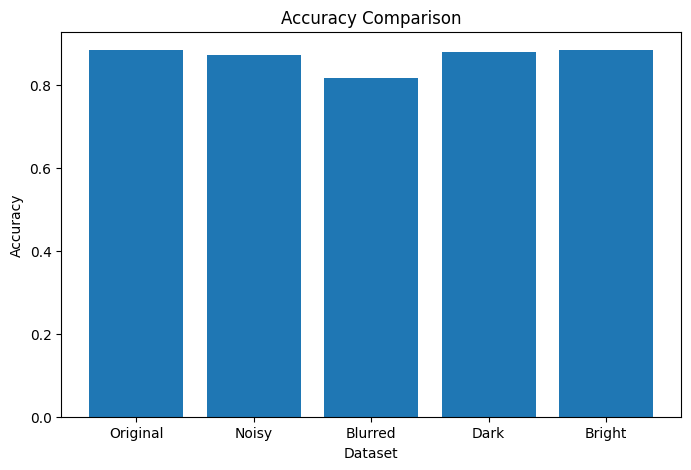

In [44]:
# Accuracy comparison bar chart

plt.figure(figsize=(8,5))

plt.bar(
    performance["Image Condition"],
    performance["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")

plt.show()

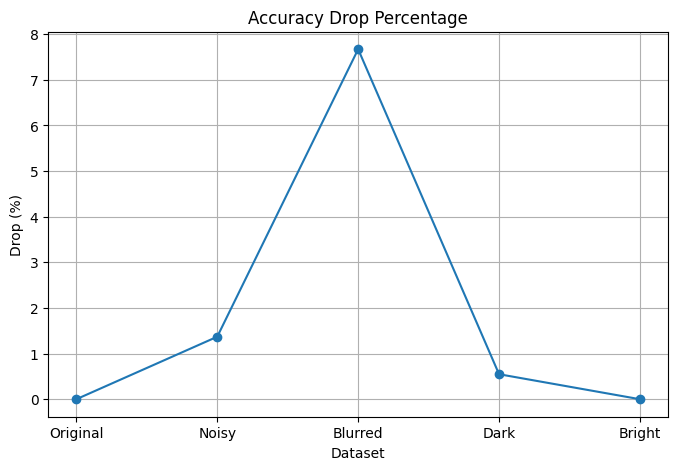

In [45]:
# Accuracy drop plot

plt.figure(figsize=(8,5))

plt.plot(
    drop_df["Image Condition"],
    drop_df["Accuracy Drop (%)"],
    marker="o"
)

plt.title("Accuracy Drop Percentage")
plt.xlabel("Dataset")
plt.ylabel("Drop (%)")

plt.grid(True)

plt.show()

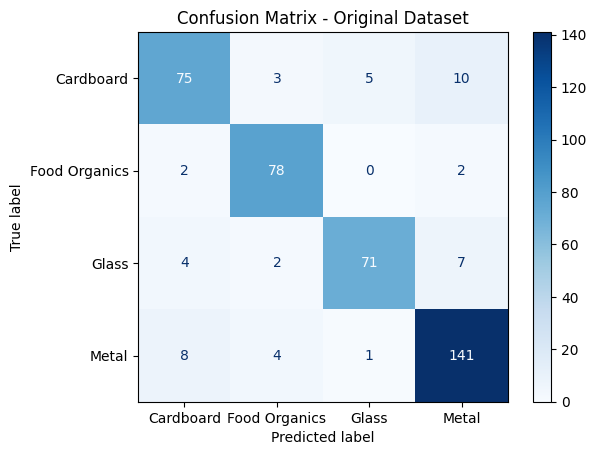

In [46]:
# Confusion Matrix

cm = results["Original"]["Confusion"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=results["Original"]["Classes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Original Dataset")

plt.show()